In [27]:
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ( accuracy_score , f1_score , recall_score , precision_score , confusion_matrix , classification_report )
sns.set_theme(style="whitegrid" , rc={"grid.linestyle":"--" ,"grid.color":"#cccccc" })


## Partie 1 — Exploration des données

In [2]:
data = pd.read_csv("../data/dataset_reussite_etudiants_300.csv")
data.shape
data.head(8)

,heures_etude_semaine,taux_presence_pct,exercices_realises,note_controle_continu,temps_plateforme_h_semaine,devoirs_rendus,participation_classe_10,reussite
0,4.8,78.6,24,16.9,11.8,4,9.5,1
1,9.0,64.5,17,6.3,6.3,8,6.3,0
2,1.0,92.1,23,11.6,7.1,9,8.3,0
3,13.6,98.8,6,14.1,5.1,9,5.9,1
4,10.6,78.8,16,13.4,9.4,6,6.6,0
5,6.8,99.8,20,6.4,5.1,5,4.1,0
6,6.8,76.5,18,16.0,6.6,10,1.8,1
7,9.2,55.0,30,13.6,2.7,6,5.5,0


In [3]:
data.info()
print(" \n Toutes les features sont numeriques (int,float )")
print(f"On a {data.shape[0]} lignes ou enregistrements et {data.shape[1]} features")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 8 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   heures_etude_semaine        300 non-null    float64
 1   taux_presence_pct           297 non-null    float64
 2   exercices_realises          300 non-null    int64  
 3   note_controle_continu       297 non-null    float64
 4   temps_plateforme_h_semaine  297 non-null    float64
 5   devoirs_rendus              300 non-null    int64  
 6   participation_classe_10     300 non-null    float64
 7   reussite                    300 non-null    int64  
dtypes: float64(5), int64(3)
memory usage: 18.9 KB
 
 Toutes les features sont numeriques (int,float )
On a 300 lignes ou enregistrements et 8 features


## Resumé statistique

In [4]:
data.describe().round(2)

,heures_etude_semaine,taux_presence_pct,exercices_realises,note_controle_continu,temps_plateforme_h_semaine,devoirs_rendus,participation_classe_10,reussite
count,300.00,297.00,300.00,297.00,297.00,300.00,300.00,300.00
mean,8.39,77.63,18.22,12.13,5.32,6.80,6.41,0.54
std,4.09,12.88,6.78,2.92,2.42,2.33,1.98,0.50
min,1.00,40.00,2.00,5.00,0.50,1.00,1.00,0.00
25%,5.30,68.30,14.00,10.20,3.60,5.00,4.90,0.00
50%,8.40,78.30,18.00,12.20,5.20,7.00,6.30,1.00
75%,11.00,87.20,23.00,14.10,7.00,9.00,8.00,1.00
max,20.00,100.00,30.00,20.00,13.80,10.00,10.00,1.00


##  Valeurs manquantes

In [5]:
miss = data.isnull().sum()
miss = miss[miss>0]
print( f"On a {data.isnull().sum().sum()} valeurs manquantes repartient comme suit:")
miss

On a 9 valeurs manquantes repartient comme suit:


taux_presence_pct             3
note_controle_continu         3
temps_plateforme_h_semaine    3
dtype: int64

## Doublons

In [6]:
doublon = data.duplicated().sum()
print(f"on a {doublon} doublon dans le dataset")

on a 0 doublon dans le dataset


## Partie 2 — Analyse des données

## TARGET

## Distribution de la variable Cible

In [7]:
target = data["reussite"].value_counts(normalize=True)
target

reussite
1    0.543333
0    0.456667
Name: proportion, dtype: float64

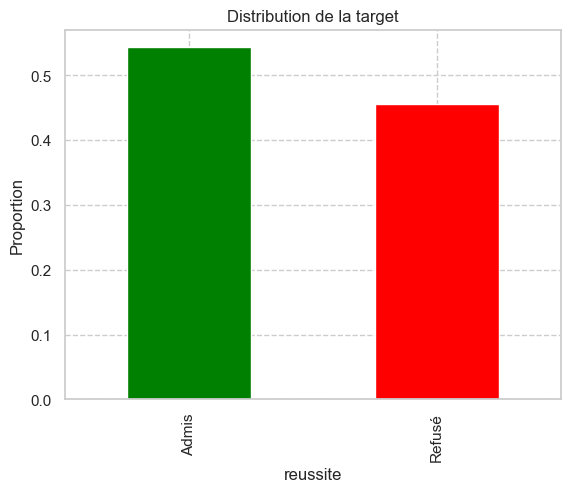

In [8]:

target.plot(kind="bar",color=["green" , "red"] )
plt.xticks([0,1],["Admis" , "Refusé"])
plt.ylabel("Proportion")
plt.title("Distribution de la target")
plt.show()

### Interprétation de la distribution de la variable cible (`reussite`)

* **Équilibre des classes** : Le diagramme en barres montre la proportion de la variable cible `reussite` (Admis vs Refusé). On observe une répartition relativement équilibrée des classes, avec environ 54-55 % d'étudiants admis (barre verte) contre environ 45-46 % d'étudiants refusés (barre rouge).
* **Absence de déséquilibre critique (Imbalance)** : Le jeu de données ne présente pas de déséquilibre de classes sévère (pas de ratio extrême type 90/10).

##  FEATURES 

In [9]:
numerical =  data.select_dtypes(include="number").columns.to_list()
numerical.remove("reussite")
numerical

['heures_etude_semaine',
 'taux_presence_pct',
 'exercices_realises',
 'note_controle_continu',
 'temps_plateforme_h_semaine',
 'devoirs_rendus',
 'participation_classe_10']

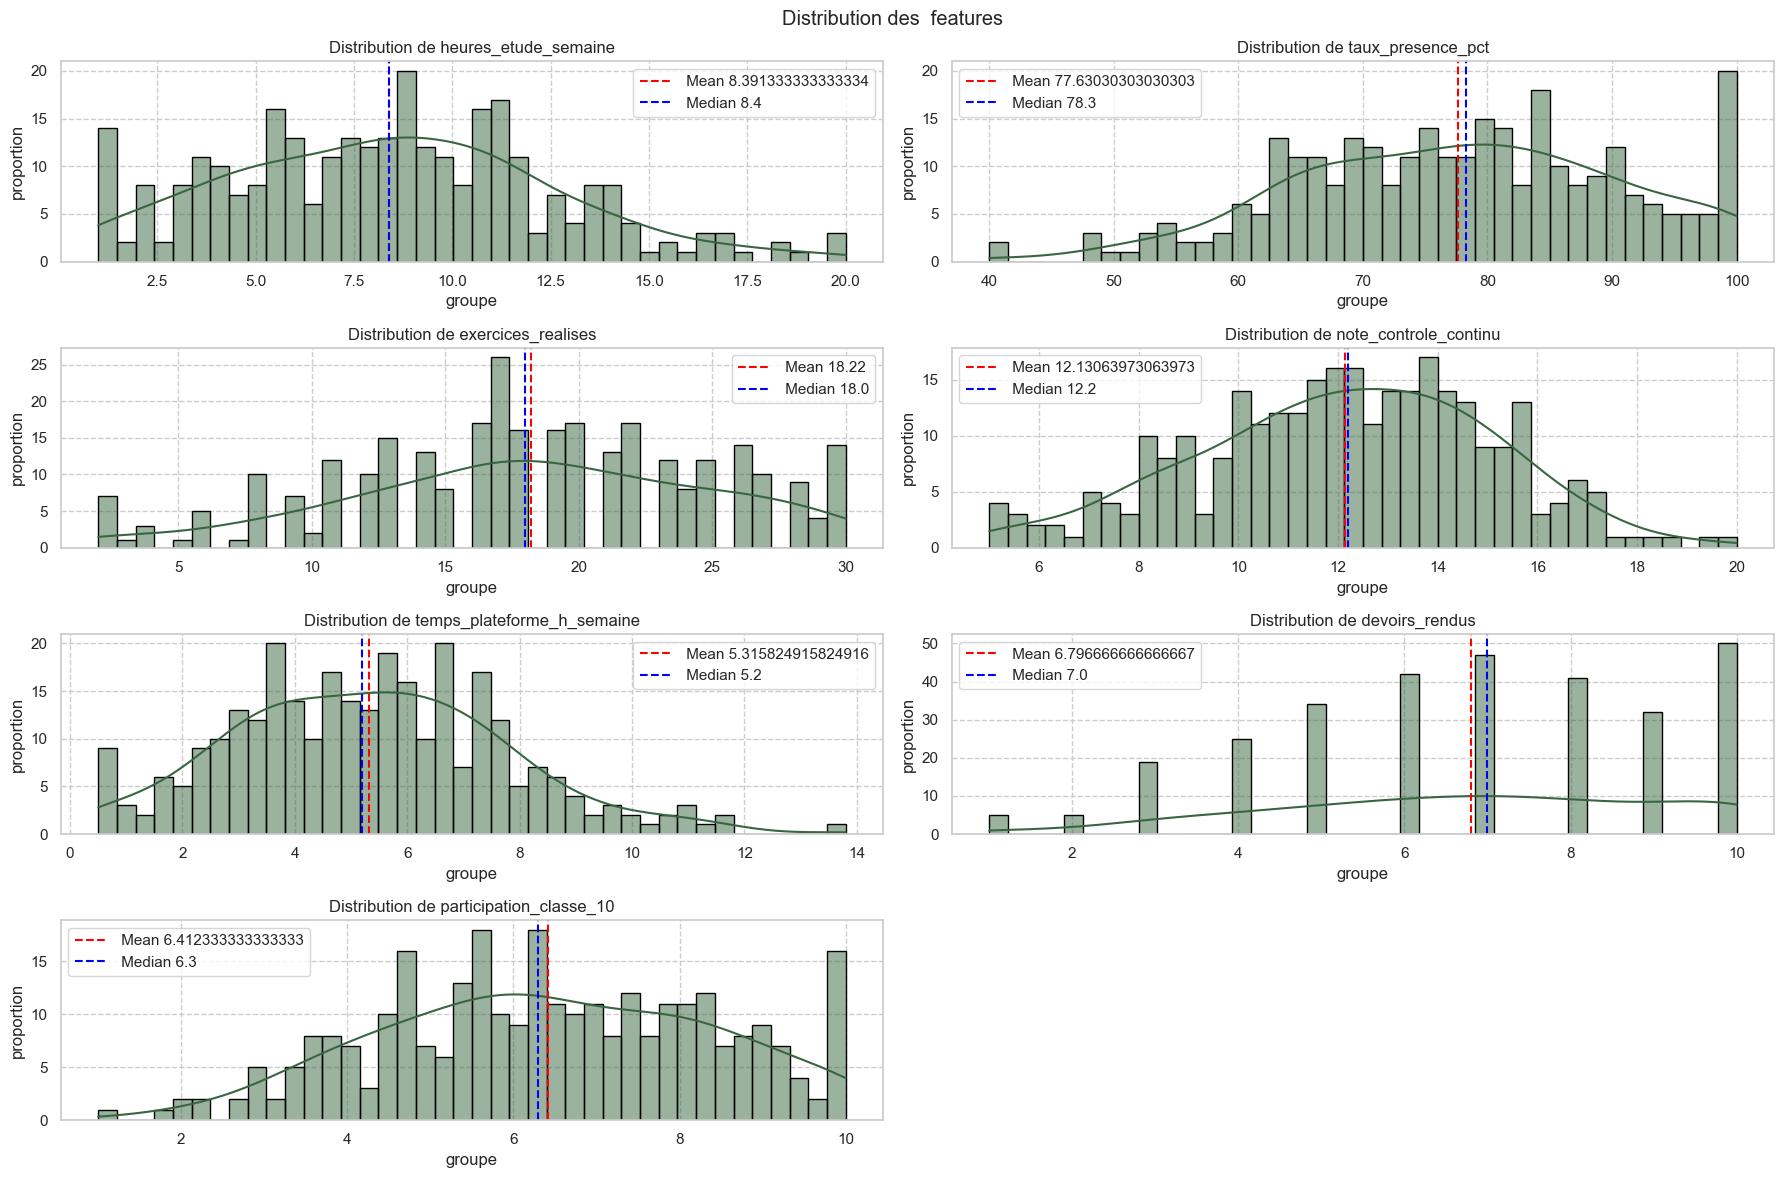

In [22]:
fig , ax  = plt.subplots( 4,2,figsize=(18,12))
ax = ax.flatten()
for index , val in enumerate (numerical):
    sns.histplot(data = data , x=val , bins=40 , edgecolor="black" , kde=True , color="#386641" ,ax = ax[index])
    ax[index].set( title=f"Distribution de {val}" , xlabel="groupe" , ylabel="proportion")
    ax[index].axvline(data[val].mean() , linestyle="--" , color="red" , label=f" Mean {data[val].mean()}")
    ax[index].axvline(data[val].median() , linestyle="--" , color="blue" , label=f" Median {data[val].median()}")
    ax[index].legend()
    
for i in range(len(numerical) , len(ax)):
    fig.delaxes(ax[i])
plt.suptitle("Distribution des  features")   
plt.tight_layout()
plt.savefig(f"../image/UNIVARIE/histplot")
plt.show()
    

### Interprétation des distributions univariées (Histogrammes)

* **`heures_etude_semaine`** : Présente une distribution légèrement asymétrique vers la droite, avec une moyenne (8.39h) et une médiane (8.4h) très proches.
* **`taux_presence_pct`** : La courbe de densité indique une concentration forte des étudiants ayant un taux de présence supérieur à 70 %.
* **`exercices_realises`** : Une distribution étalée avec une moyenne de 18.22 exercices et une médiane à 18.0.
* **`note_contrôle_continu`** : Suit une allure proche d'une loi normale (cloche), centrée autour d'une moyenne de 12.13 et d'une médiane de 12.2 sur 20.
* **`temps_plateforme_h_semaine`** : Asymétrie positive modérée, la majorité des étudiants passant entre 4 et 7 heures par semaine sur la plateforme.
* **`devoirs_rendus`** : Distribution discrète asymétrique, révélant que de nombreux étudiants ont tendance à rendre un nombre élevé de devoirs (notamment 7 à 10).
* **`participation_classe_10`** : Une répartition équilibrée de la participation, oscillant majoritairement entre 5 et 9 sur 10.

In [12]:
data.describe()

,heures_etude_semaine,taux_presence_pct,exercices_realises,note_controle_continu,temps_plateforme_h_semaine,devoirs_rendus,participation_classe_10,reussite
count,300.000000,297.000000,300.000000,297.000000,297.000000,300.000000,300.000000,300.000000
mean,8.391333,77.630303,18.220000,12.130640,5.315825,6.796667,6.412333,0.543333
std,4.094240,12.875011,6.780722,2.922323,2.415977,2.326664,1.979514,0.498951
min,1.000000,40.000000,2.000000,5.000000,0.500000,1.000000,1.000000,0.000000
25%,5.300000,68.300000,14.000000,10.200000,3.600000,5.000000,4.900000,0.000000
50%,8.400000,78.300000,18.000000,12.200000,5.200000,7.000000,6.300000,1.000000
75%,11.000000,87.200000,23.000000,14.100000,7.000000,9.000000,8.000000,1.000000
max,20.000000,100.000000,30.000000,20.000000,13.800000,10.000000,10.000000,1.000000


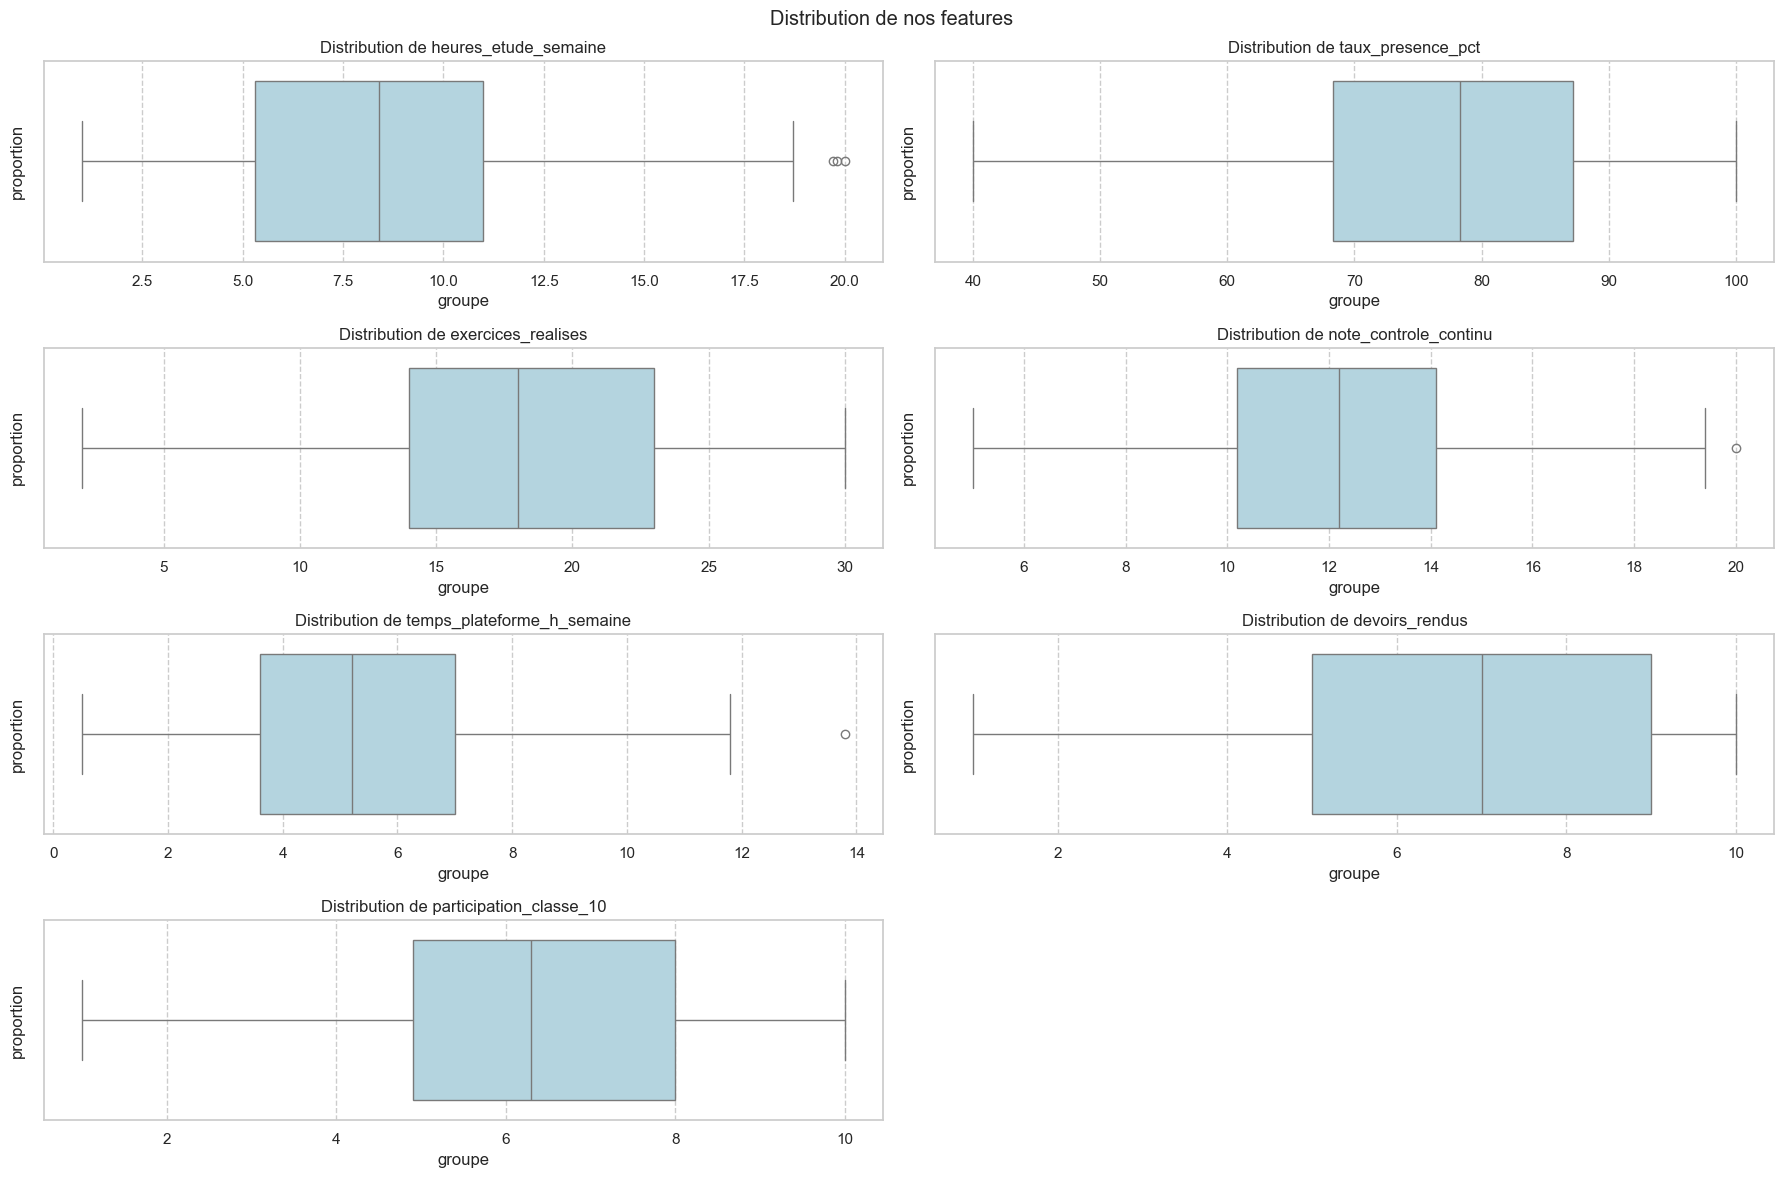

In [23]:
fig , ax  = plt.subplots( 4,2,figsize=(18,12))
ax = ax.flatten()
for index , val in enumerate (numerical):
    sns.boxplot(data = data , x=val ,color="lightblue" ,ax = ax[index])
    ax[index].set( title=f"Distribution de {val}" , xlabel="groupe" , ylabel="proportion")
for i in range(len(numerical) , len(ax)):
    fig.delaxes(ax[i])

plt.suptitle("Distribution de nos features")
plt.tight_layout()
plt.savefig(f"../image/UNIVARIE/boxplot")
plt.show()
    

### Interprétation des boîtes à moustaches (Boxplots)

* **`heures_etude_semaine`** : La médiane se situe autour de 8-9 heures. La distribution montre quelques valeurs extrêmes (outliers) au-delà de 17.5 heures d'étude par semaine.
* **`taux_presence_pct`** : Les taux de présence sont globalement élevés, centrés autour de 78-80 %, avec une étendue allant d'environ 40 % à 100 %.
* **`exercices_realises`** : Une répartition homogène avec une médiane proche de 18 exercices, s'étalant de 2 à 30.
* **`note_contrôle_continu`** : La majorité des notes se concentrent entre 10 et 14 sur 20, avec une valeur atypique isolée proche de 20.
* **`temps_plateforme_h_semaine`** : Le temps médian passé sur la plateforme est d'environ 5 heures par semaine, avec un outlier marqué au-delà de 13 heures.
* **`devoirs_rendus`** : La médiane se situe à 7 devoirs rendus, avec une plage de variation allant de 1 à 10.
* **`participation_classe_10`** : Le niveau de participation est homogène avec une médiane à environ 6.2/10, s'étendant de 1 à 10.

## ANALYSE BIVARIEE

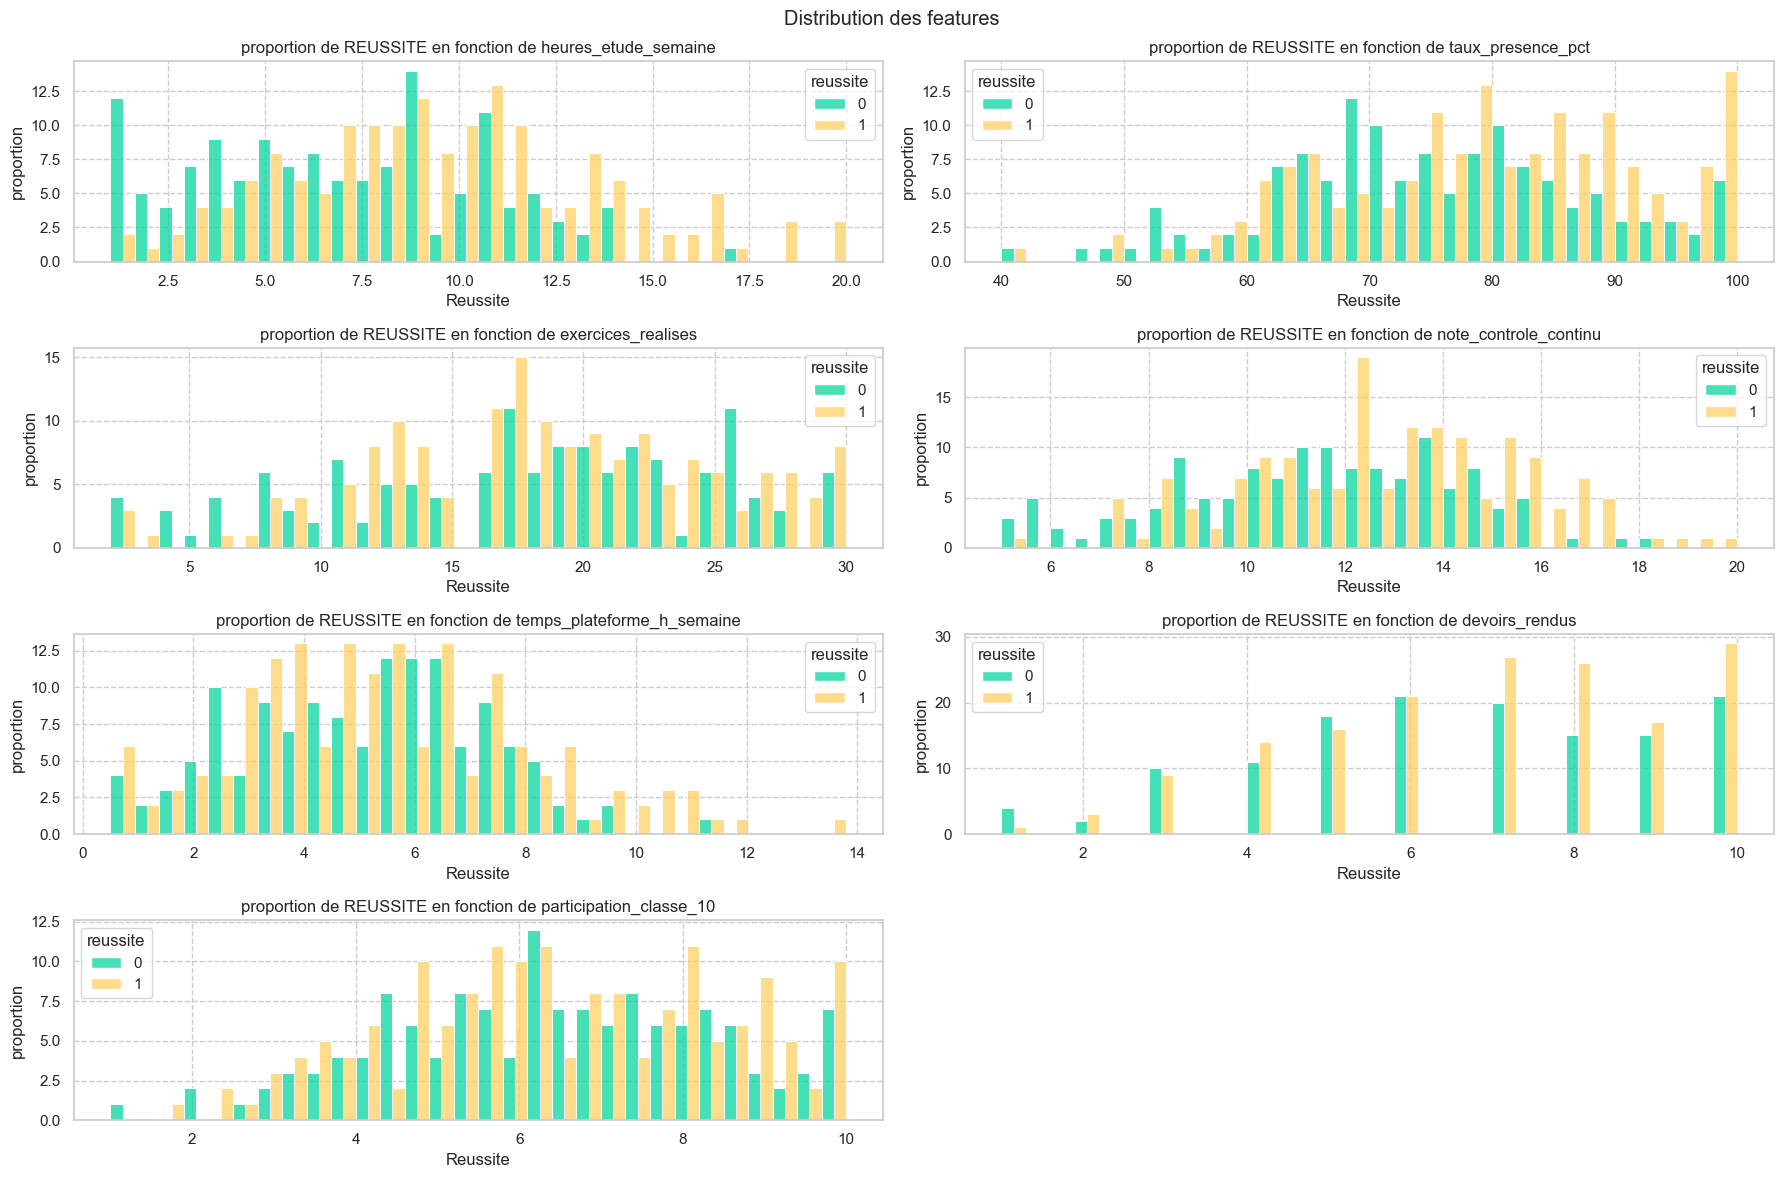

In [26]:
fig , ax  = plt.subplots( 4,2,figsize=(18,12))
ax = ax.flatten()
for index , val in enumerate (numerical):
 sns.histplot(data=data , x=val , bins=30, hue='reussite', multiple="dodge", palette=["#06d6a0","#ffd166"], ax =ax[index])
 ax[index].set(title=f'proportion de REUSSITE en fonction de {val}',xlabel='Reussite',ylabel='proportion')
 
for i in range (len(numerical) , len(ax)):
    fig.delaxes(ax[i])
 
    

plt.suptitle("Distribution des features")
plt.tight_layout()
plt.savefig(f"../image/BIVARIE/histplot")
plt.show()
    

### Interprétation bivariée : Impact des features sur la Réussite (`reussite`)

* **`heures_etude_semaine`** : On observe visuellement que les étudiants ayant des volumes d'études hebdomadaires plus élevés (notamment au-delà de 10-12 heures) appartiennent plus fréquemment à la classe des admis (`reussite = 1`, en orange/jaune).
* **`taux_presence_pct`** : Un taux de présence élevé (> 75-80 %) est nettement associé à une plus forte proportion de succès à l'examen final.
* **`note_contrôle_continu`** : Les étudiants obtenant de bonnes notes en contrôle continu (12 et plus) réussissent largement plus souvent leur examen.
* **`temps_plateforme_h_semaine` & `devoirs_rendus`** : Une constance dans le rendu des devoirs et l'utilisation de la plateforme tend à faire basculer la proportion en faveur de la réussite (`1`), consolidant l'importance de l'engagement continu.

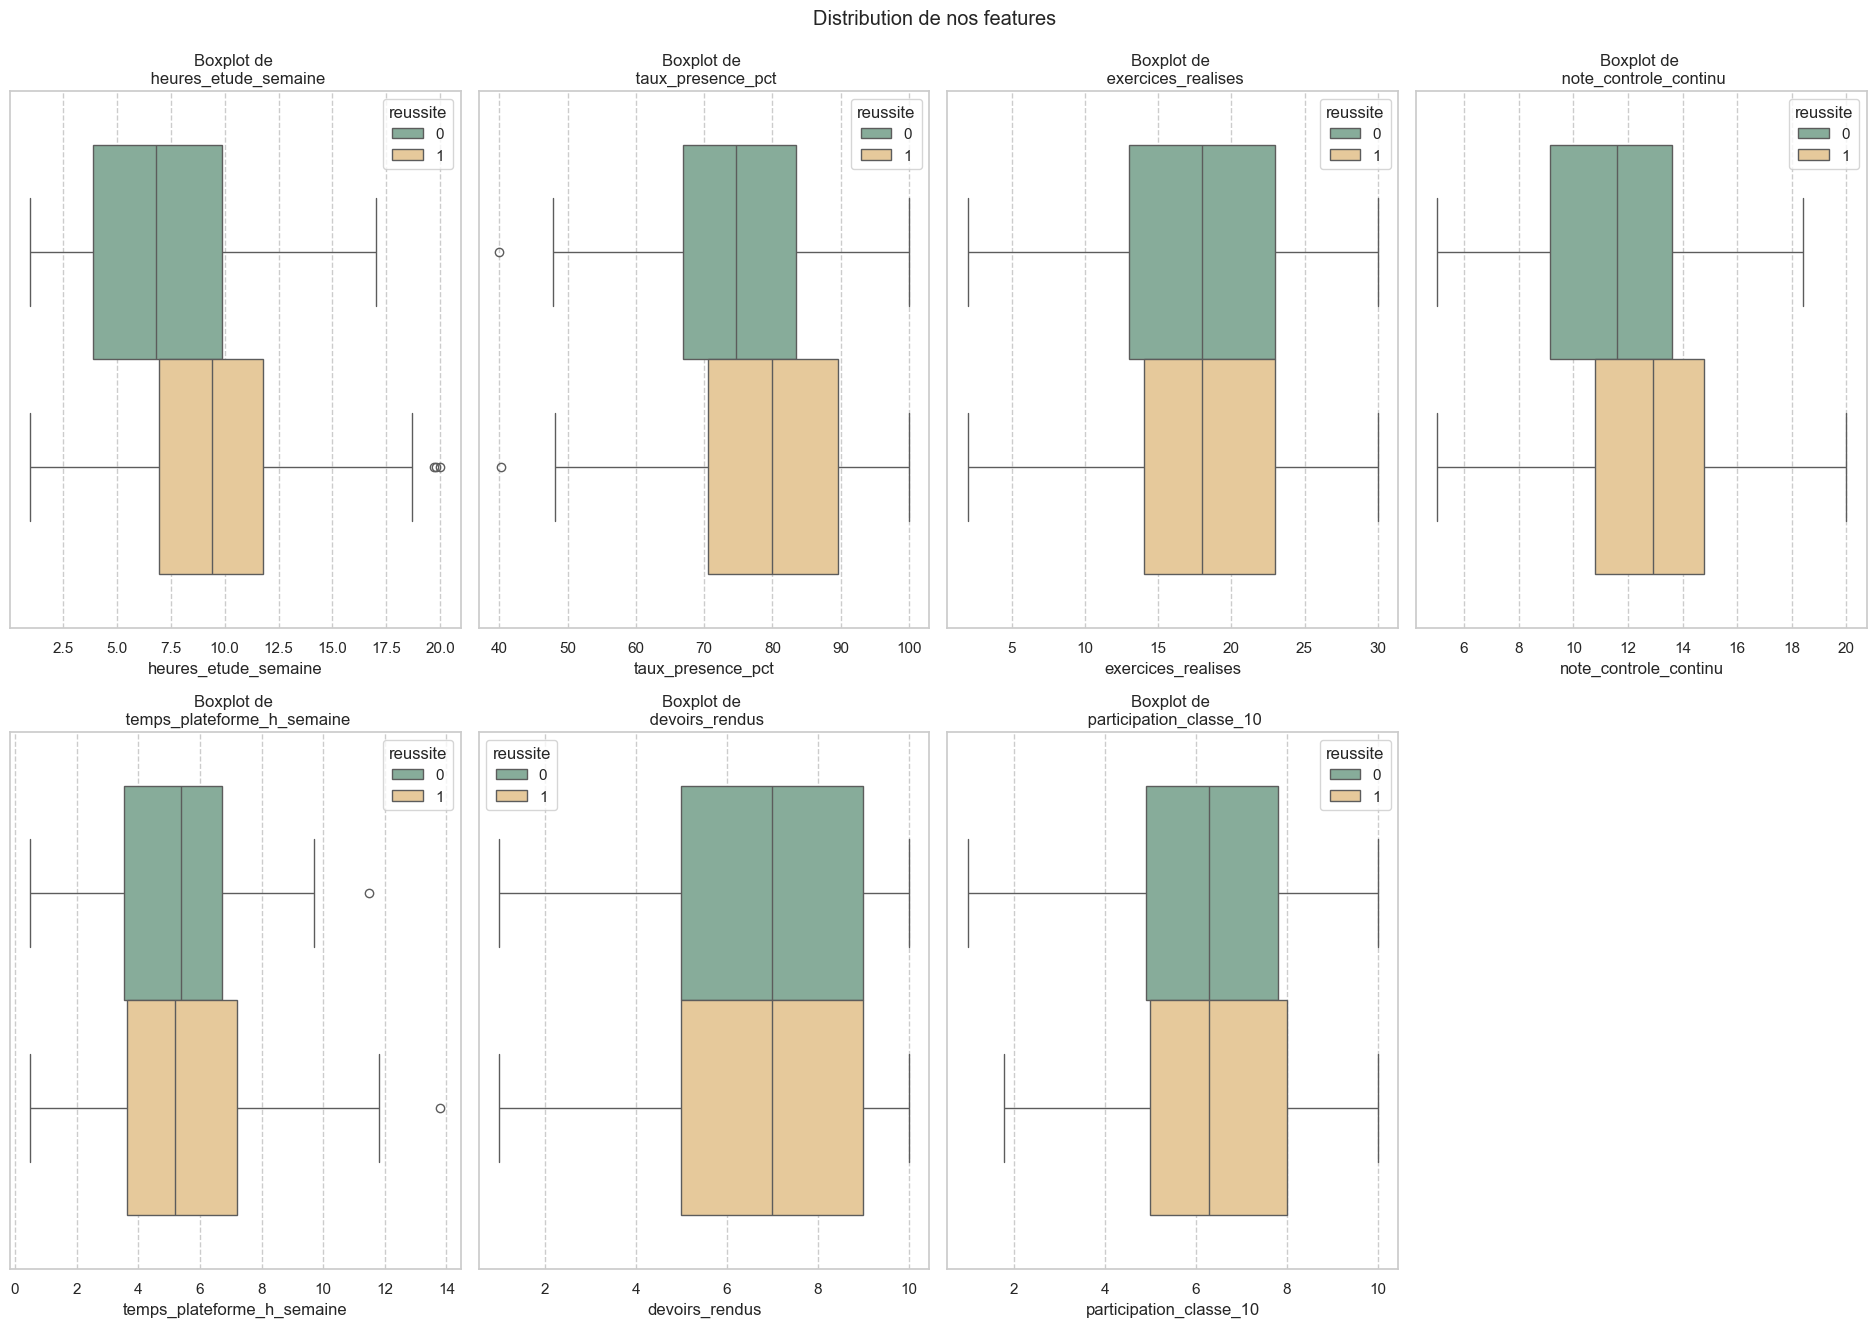

In [16]:
fig, ax = plt.subplots(2, 4, figsize=(19, 13))
ax = ax.flatten()

for index, val in enumerate(numerical):
    
    sns.boxplot(
        data=data,
        x=val,
        hue="reussite",
        palette=["#81b29a", "#f2cc8f"],
        ax=ax[index],
    )
    ax[index].set(title=f"Boxplot de \n {val}")

for i in range(len(numerical), len(ax)):
    fig.delaxes(ax[i])

plt.tight_layout()
plt.suptitle("Distribution de nos features", y=1.02)
plt.savefig("../image/BIVARIE/boxplot.png")  
plt.show()

### Interprétation des boxplots bivariés (Impact de chaque feature sur la Réussite)

* **`heures_etude_semaine`** : On observe une différence nette entre les deux groupes. Les étudiants ayant réussi (`1`, en beige) affichent une médiane et des quartiles significativement plus élevés que ceux en échec (`0`, en vert). Étudier plus d'heures par semaine est fortement corrélé au succès.
* **`taux_presence_pct`** : La boîte des étudiants admis est globalement décalée vers des pourcentages de présence plus élevés. Un taux de présence supérieur à 70-80 % favorise nettement la réussite.
* **`exercices_realises`** : Les distributions sont relativement proches, montrant que la quantité brute d'exercices réalisés seule a un impact visuel plus nuancé, bien que la médiane des réussites tende légèrement vers le haut.
* **`note_controle_continu`** : Présente une distinction claire. Les étudiants admis possèdent une médiane de notes en contrôle continu nettement supérieure à celle des étudiants en échec, ce qui en fait un excellent indicateur prédictif.
* **`temps_plateforme_h_semaine`** & **`devoirs_rendus`** & **`participation_classe_10`** : Les médianes et dispersions entre les deux groupes restent très proches. Ces variables ont un pouvoir discriminant un peu plus faible prises isolément, mais apportent des informations complémentaires utiles pour le modèle de Machine Learning.

## ETUDE DE CORRELATION

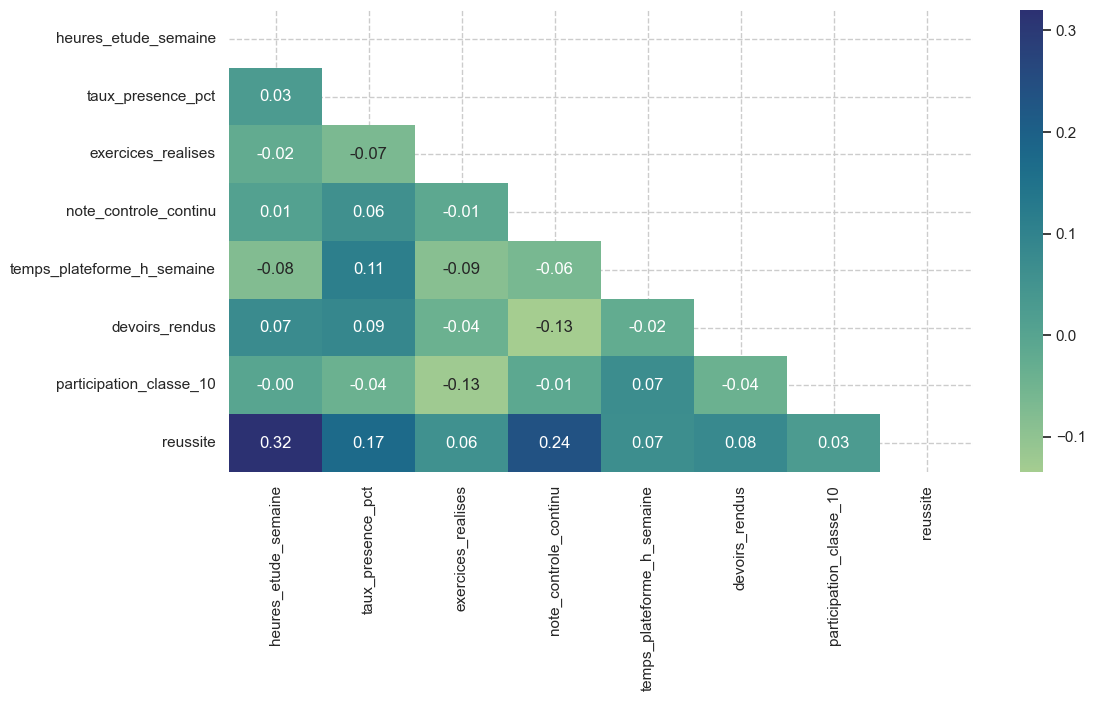

In [17]:
corr = data.corr()
plt.figure(figsize=(12,6))
mask = np.triu(np.ones_like(corr , dtype= bool))
sns.heatmap(corr , annot=True, mask=mask , fmt=".2f" , cmap="crest")
plt.savefig("../image/CORRELATION/heatmap.png")  # Ajout de l'extension .png
        


### Interprétation de la matrice de corrélation (Heatmap)

* **Corrélation avec la cible (`reussite`)** : 
  * La variable **`heures_etude_semaine`** présente la corrélation positive la plus forte avec la réussite ($r = 0.32$), ce qui en fait un prédicateur clé.
  * La **`note_contrôle_continu`** montre également une corrélation positive marquée ($r = 0.24$).
  * Le **`taux_presence_pct`** affiche une corrélation positive modérée ($r = 0.17$).
* **Colinéarité entre features** : Les corrélations entre les variables explicatives indépendantes restent globalement faibles à modérées, ce qui limite les risques majeurs de multicolinéarité pour les modèles de Machine Learning.

ici on a un beau dataset qui ne presente pas de colinéarité du coup chaue variable apporte une information differente excepter quelques faible correlation negative

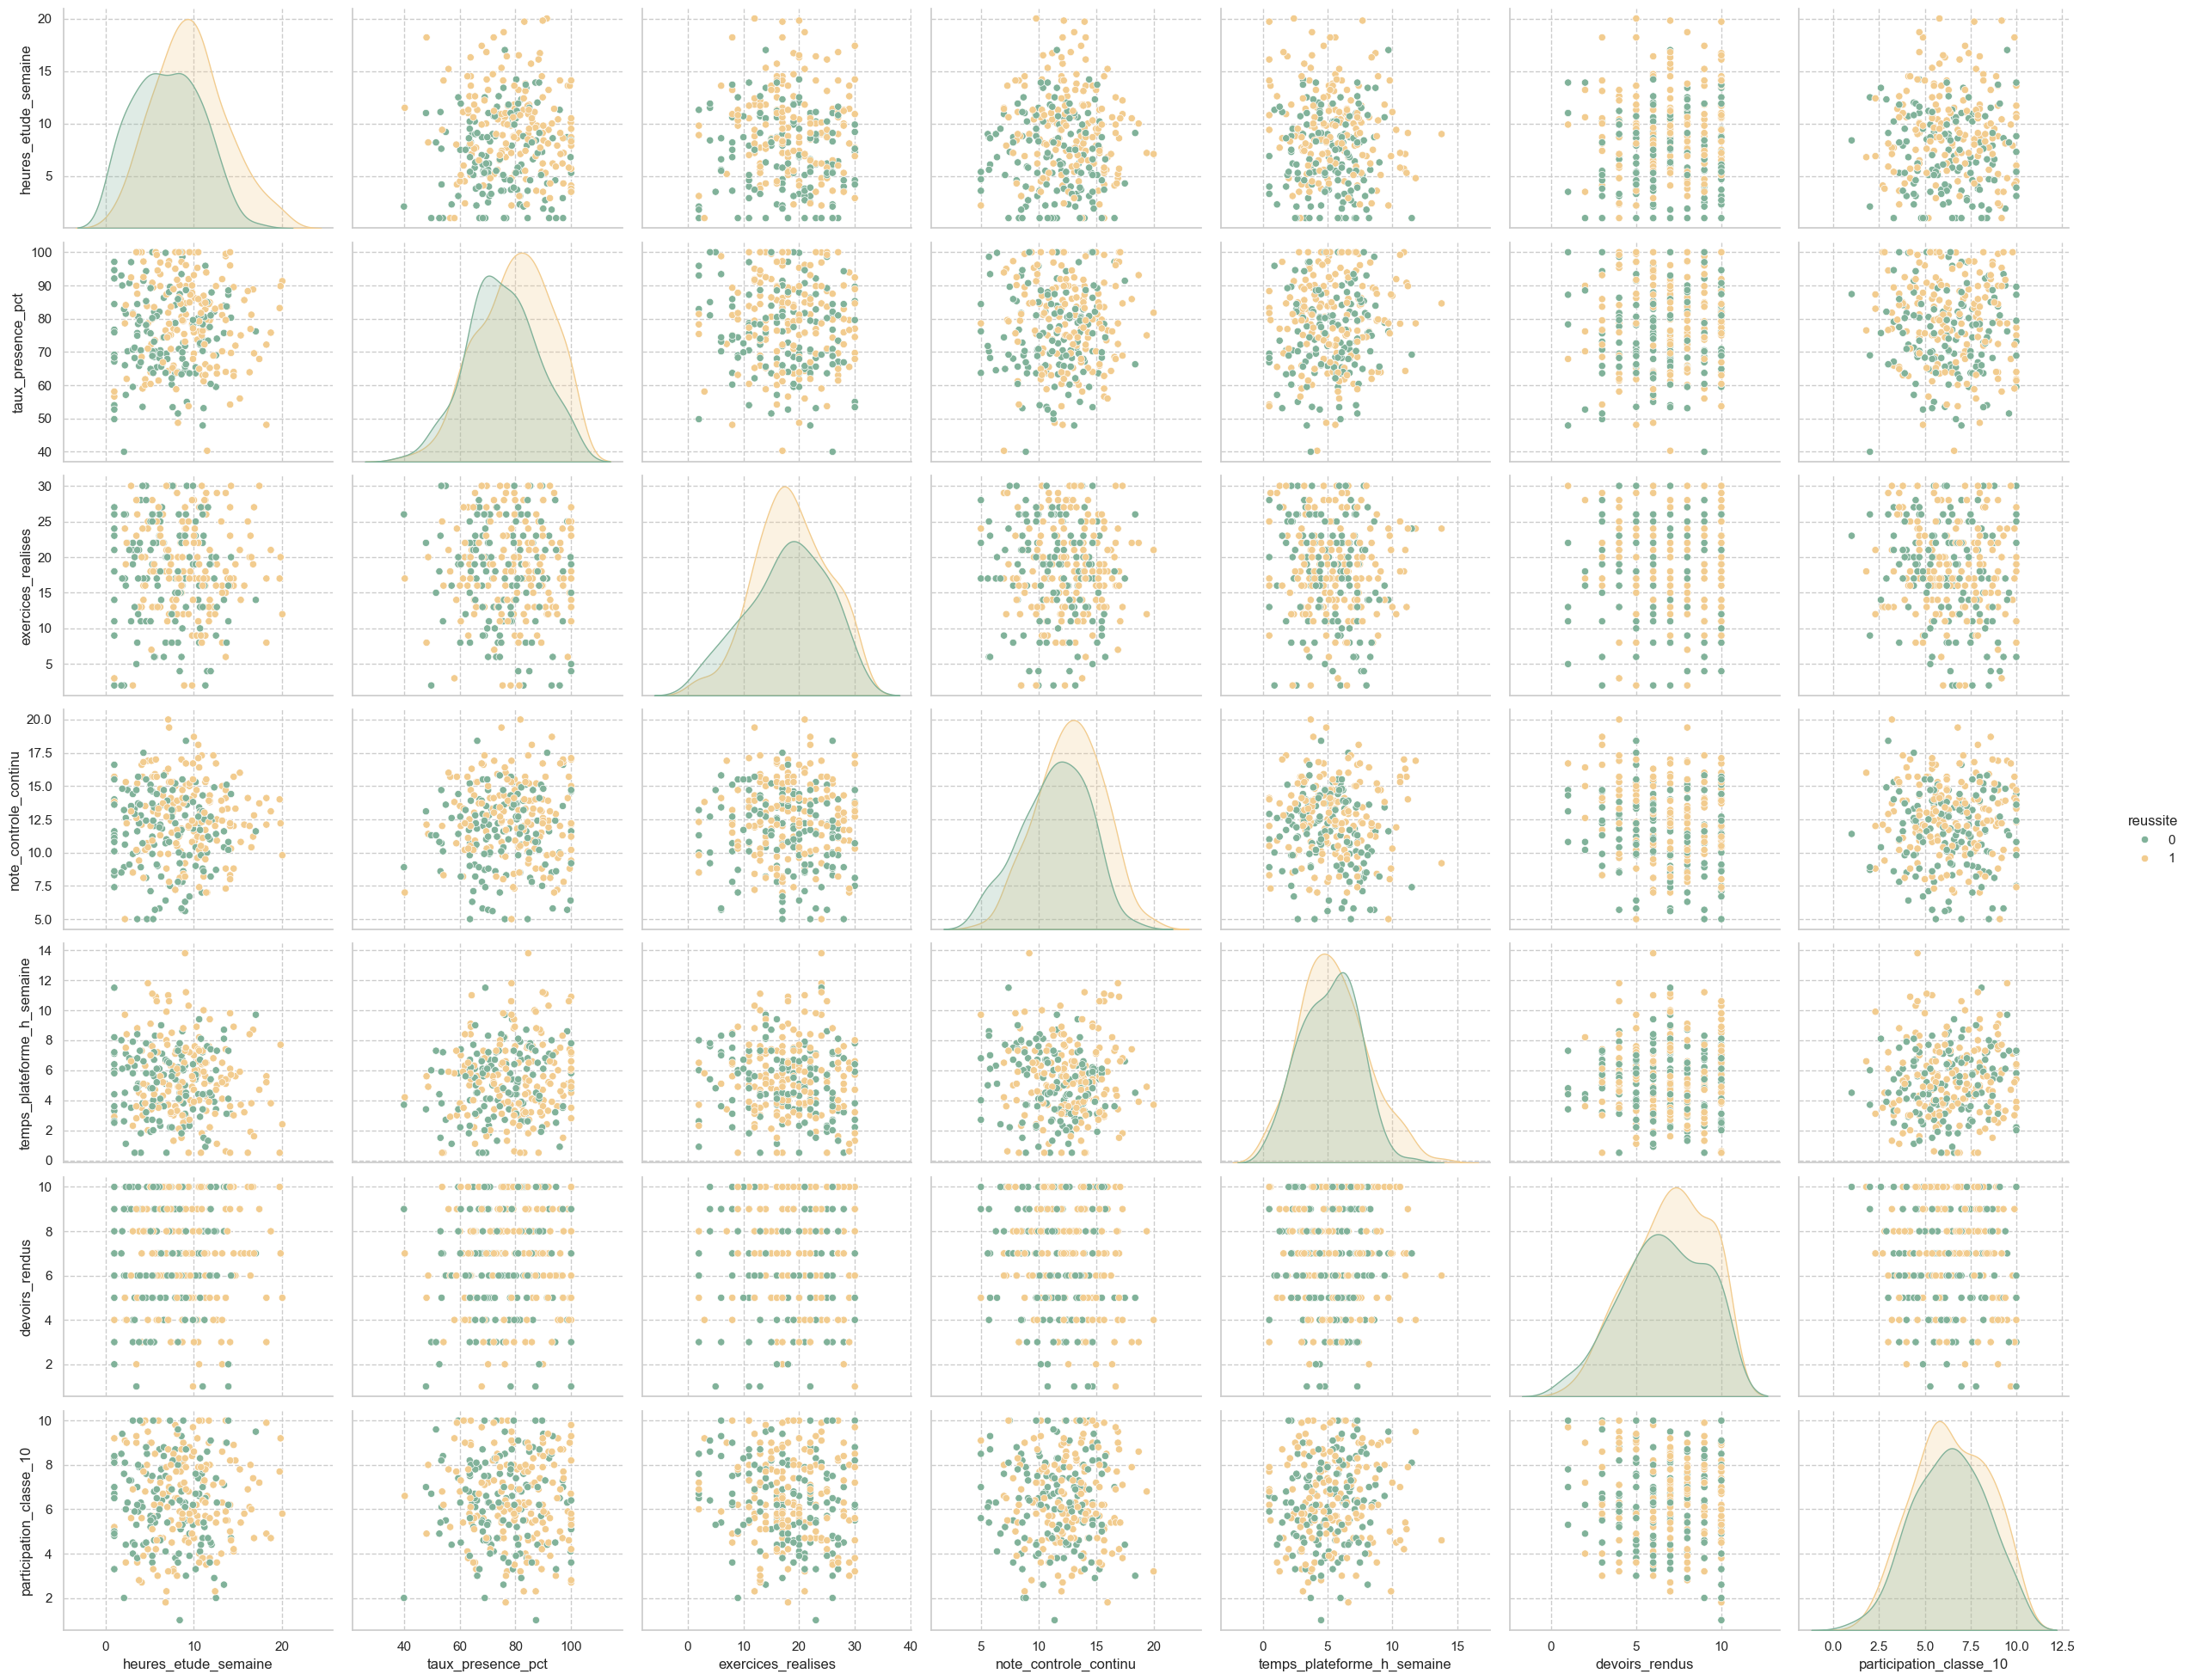

In [20]:
g = sns.pairplot(data=data, hue="reussite", palette=["#81b29a", "#f2cc8f"])
g.fig.set_size_inches(26, 20)  # Applique la grande taille souhaitée
g.savefig("../image/CORRELATION/pairplot")
plt.show()

# Bilan Final de l'Analyse Exploratoire des Données (EDA)

## 1. Structure et Qualité des Données
* **Volume et dimensions** : Le jeu de données contient exactement **300 enregistrements (lignes)** et **8 variables (features)**, offrant une base de données de taille correcte pour amorcer la modélisation.
* **Types de variables** : Toutes les variables du dataset sont **numériques** (entiers ou décimaux).
* **Duplicatas** : **0 doublon** n'a été détecté dans le jeu de données, ce qui garantit l'unicité de chaque observation.
* **Valeurs manquantes** : Le dataset présente un très faible taux de valeurs manquantes (seulement **9 valeurs manquantes** au total, réparties de manière égale sur trois colonnes) :
  * `taux_presence_pct` : 3 valeurs manquantes
  * `note_controle_continu` : 3 valeurs manquantes
  * `temps_plateforme_h_semaine` : 3 valeurs manquantes
  

---

## 2. Analyse Univariée & Distributions
* **Comportement des features** : 
  * Les boîtes à moustaches (*boxplots*) et histogrammes ont permis d'identifier les tendances centrales (moyennes et médianes proches) et de repérer quelques valeurs aberrantes (*outliers*) mineures, notamment sur les heures d'études et le temps passé sur la plateforme.
* **Variable Cible (`reussite`)** : 
  * La distribution de la target montre un **bon équilibre des classes** (environ 54-55 % d'admis contre 45-46 % de refusés). 
  * Ce profil équilibré évite d'avoir recours à des techniques lourdes de rééchantillonnage (type SMOTE), tout en permettant d'évaluer les futurs modèles de Machine Learning de manière fiable.

---

## 3. Analyse Bivariée & Multivariée
* **Impact des features sur la réussite** : 
  * L'analyse croisée (via les boxplots et histplots segmentés par `hue="reussite"`) met en évidence que les étudiants réussissant leur examen se distinguent par des **volumes d'heures d'étude hebdomadaires plus élevés**, un **taux de présence supérieur à 75-80 %**, et de **meilleures notes en contrôle continu**.
* **Indépendance et Colinéarité** : 
  * La matrice de corrélation (*heatmap*) et la matrice de croisement (*pairplot*) confirment une **forte variance** des données et une **absence de multicolinéarité sévère** entre les variables explicatives.
  * Chaque feature apporte une information comportementale ou académique unique et complémentaire.

---
### Interprétation de la matrice de croisement (Pairplot)

* **Absence de colinéarité marquée** : Les nuages de points (scatter plots) hors diagonale ne montrent pas de relations linéaires strictes ou de formes en lignes diagonales serrées entre les variables explicatives. Cela confirme l'absence de multicolinéarité majeure : chaque feature apporte une information unique et non redondante pour le modèle.
* **Complémentarité de l'information** : La dispersion des points (forte variance) indique que les variables mesurent des aspects comportementaux et académiques bien distincts de l'étudiant.
* **Séparabilité des classes (`reussite`)** : En observant la diagonale (distributions univariées) et les croisements, on distingue des décalages de densité entre la classe d'échec (`0`, en vert) et de réussite (`1`, en orange/jaune), en particulier sur des variables comme `heures_etude_semaine` ou `note_controle_continu`. Cela valide l'intérêt de combiner l'ensemble de ces variables au sein d'un algorithme de Machine Learning pour capturer la complexité de la réussite étudiante.

## 4. Conclusion & Prochaines Étapes
Notre EDA est **complète**. Le jeu de données est sain, sans redondance excessive et bien structuré. 



## Partie 3 — Préparation des données


In [28]:
data

,heures_etude_semaine,taux_presence_pct,exercices_realises,note_controle_continu,temps_plateforme_h_semaine,devoirs_rendus,participation_classe_10,reussite
0,4.8,78.6,24,16.9,11.8,4,9.5,1
1,9.0,64.5,17,6.3,6.3,8,6.3,0
2,1.0,92.1,23,11.6,7.1,9,8.3,0
3,13.6,98.8,6,14.1,5.1,9,5.9,1
4,10.6,78.8,16,13.4,9.4,6,6.6,0
...,...,...,...,...,...,...,...,...
295,7.5,62.1,12,13.2,5.6,6,6.9,0
296,9.1,88.6,13,14.1,4.3,8,8.7,0
297,19.8,89.8,20,12.2,7.7,7,9.2,1
298,11.2,72.3,28,13.0,5.1,7,7.3,1


In [29]:
X = data.drop(columns = "reussite" , axis=1)
Y = data["reussite"]

In [30]:
X.head()

,heures_etude_semaine,taux_presence_pct,exercices_realises,note_controle_continu,temps_plateforme_h_semaine,devoirs_rendus,participation_classe_10
0,4.8,78.6,24,16.9,11.8,4,9.5
1,9.0,64.5,17,6.3,6.3,8,6.3
2,1.0,92.1,23,11.6,7.1,9,8.3
3,13.6,98.8,6,14.1,5.1,9,5.9
4,10.6,78.8,16,13.4,9.4,6,6.6


In [31]:
Y.head()

0    1
1    0
2    0
3    1
4    0
Name: reussite, dtype: int64

## Separation des données en Train et Test set

In [63]:
X_train , X_test , Y_train , Y_test = train_test_split( X , Y , test_size=0.2 , stratify=Y , random_state=42)
print(f" Forme X_train: {X_train.shape} \n Forme Y_train: {Y_train.shape}")
print(f" Forme X_test: {X_test.shape} \n Forme Y_test: {X_test.shape}")



 Forme X_train: (240, 7) 
 Forme Y_train: (240,)
 Forme X_test: (60, 7) 
 Forme Y_test: (60, 7)


In [64]:
pipe_lr = Pipeline(
    steps = [
        ("impute" , SimpleImputer(strategy="median")),
        ("scaler" , StandardScaler()),
        ("LogisticR", LogisticRegression()),
        ]
)

pipe_rf = Pipeline(
    steps=[
        ("impute", SimpleImputer(strategy="median")),
        ("classifier", RandomForestClassifier(random_state=42)),
    ]
)

In [65]:
metrics= []

## Partie 4 — Création de l’IA

In [66]:
pipe_lr.fit(X_train, Y_train)
Y_pred = pipe_lr.predict(X_test)
print("#"* 50)
print(
    f"Accuracy Score: {accuracy_score(Y_test, Y_pred)} \n"
    f"Precision Score: {precision_score(Y_test, Y_pred)} \n"
    f"Recall Score: {recall_score(Y_test, Y_pred)} \n"
    f"F1 Score: {f1_score(Y_test, Y_pred)}"
)
metrics.append({ 
    "Accuracy": accuracy_score(Y_test, Y_pred),
    "Precision Score": precision_score(Y_test, Y_pred),
    "Recall Score": recall_score(Y_test, Y_pred) ,
    "F1 Score": f1_score(Y_test, Y_pred)})

##################################################
Accuracy Score: 0.75 
Precision Score: 0.75 
Recall Score: 0.8181818181818182 
F1 Score: 0.782608695652174


## Partie 5 — Évaluation

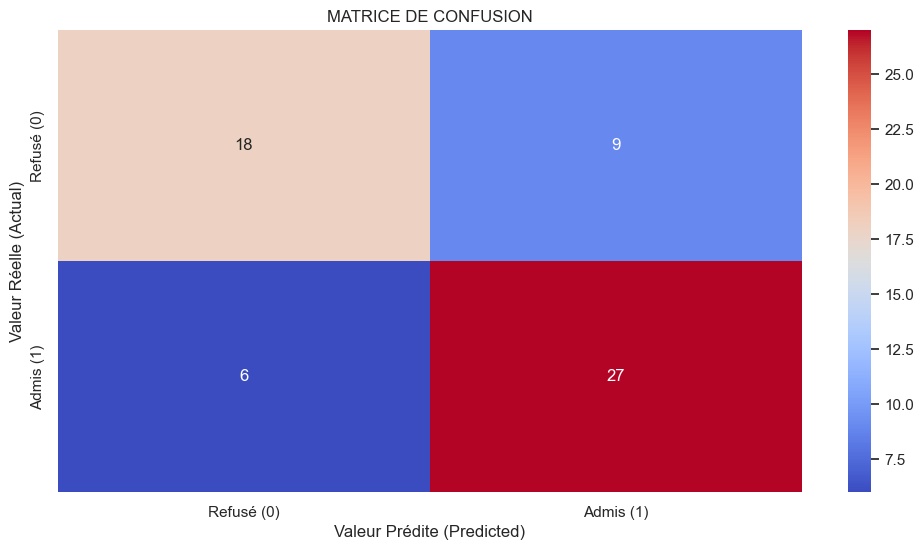

In [67]:
conf_m = confusion_matrix(Y_test,Y_pred)
plt.figure(figsize=(12,6))
ax = sns.heatmap( conf_m ,
                  annot=True, 
                  fmt="d",
                  cmap="coolwarm",
                 xticklabels=["Refusé (0)", "Admis (1)"],
                  yticklabels=["Refusé (0)", "Admis (1)"])
ax.set(
    xlabel="Valeur Prédite (Predicted)",
    ylabel="Valeur Réelle (Actual)",
    title="MATRICE DE CONFUSION",
)

plt.savefig("../image/evaluation/lregression.png")
plt.show()




#### Régression Logistique
* **Vrais Négatifs (18)** : Étudiants correctement identifiés comme *Refusés*.
* **Vrais Positifs (27)** : Étudiants correctement identifiés comme *Admis*.
* **Erreurs** : 
  * 9 faux positifs (prédits admis à tort).
  * 6 faux négatifs (étudiants admis ratés par le modèle).

## Analyse critique et justification métier

### Réponse à la problématique :
Le modèle de **Régression Logistique** s'avère pertinent et suffisamment performant pour identifier les étudiants, car il minimise le taux d'erreurs critiques sur le plan pédagogique.

### Justification à partir des résultats :
1. **Priorisation du Rappel (Recall) sur les erreurs critiques :** 
   * Dans le cadre du suivi des étudiants, un **Faux Négatif (FN)** — c'est-à-dire rater un étudiant en difficulté en le prédisant à tort comme admis — est beaucoup plus préjudiciable qu'un Faux Positif, car il prive un étudiant vulnérable du soutien dont il a besoin.
   * La Régression Logistique affiche un **Recall de 81.8 %** (contre 72.7 % pour la Forêt Aléatoire), ce qui se traduit par un nombre plus faible de faux négatifs (seulement 6 ratés contre 9 pour le Random Forest).
2. **Performance globale équilibrée :** Avec une accuracy de **75 %** et un meilleur compromis global (F1-score de **0.78**), le modèle linéaire offre une excellente fiabilité pour cibler les profils à risque tout en limitant les angles morts.

In [68]:
pipe_rf.fit(X_train, Y_train)
Y_pred = pipe_rf.predict(X_test)
print("#"* 50)
print(
    f"Accuracy Score: {accuracy_score(Y_test, Y_pred)} \n"
    f"Precision Score: {precision_score(Y_test, Y_pred)} \n"
    f"Recall Score: {recall_score(Y_test, Y_pred)} \n"
    f"F1 Score: {f1_score(Y_test, Y_pred)}"
)
metrics.append({ 
    "Accuracy": accuracy_score(Y_test, Y_pred),
    "Precision Score": precision_score(Y_test, Y_pred),
    "Recall Score": recall_score(Y_test, Y_pred) ,
    "F1 Score": f1_score(Y_test, Y_pred)})

##################################################
Accuracy Score: 0.7166666666666667 
Precision Score: 0.75 
Recall Score: 0.7272727272727273 
F1 Score: 0.7384615384615385


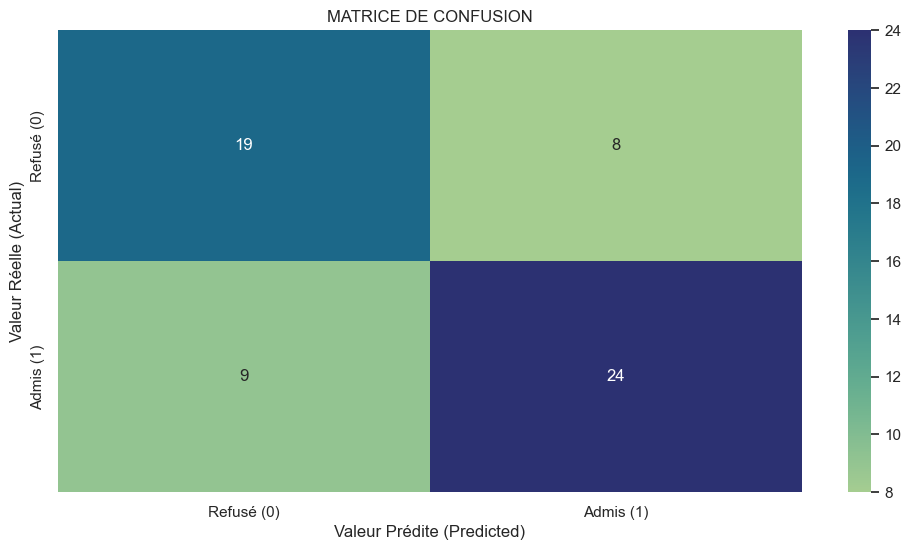

In [69]:
conf_m = confusion_matrix(Y_test,Y_pred)
plt.figure(figsize=(12,6))
ax = sns.heatmap( conf_m ,
                  annot=True, 
                  fmt="d",
                  cmap="crest",
                 xticklabels=["Refusé (0)", "Admis (1)"],
                  yticklabels=["Refusé (0)", "Admis (1)"])

ax.set(
    xlabel="Valeur Prédite (Predicted)",
    ylabel="Valeur Réelle (Actual)",
    title="MATRICE DE CONFUSION",
)
plt.savefig("../image/evaluation/rforest.png")
plt.show()




#### Forêt Aléatoire
* **Vrais Négatifs (19)** : Étudiants correctement identifiés comme *Refusés*.
* **Vrais Positifs (24)** : Étudiants correctement identifiés comme *Admis*.
* **Erreurs** :
  * 8 faux positifs (prédits admis à tort).
  * 9 faux négatifs (étudiants admis ratés par le modèle).

## 6. Bonus — Random Forest


In [75]:
compare =pd.DataFrame(metrics, index=["Regression Logistique", "Forêt aléatoire"])

In [81]:
compare.T.style.background_gradient(
    cmap="viridis", subset=["Regression Logistique", "Forêt aléatoire"]
)

,Regression Logistique,Forêt aléatoire
Accuracy,0.750000,0.716667
Precision Score,0.750000,0.750000
Recall Score,0.818182,0.727273
F1 Score,0.782609,0.738462


### 2. Comparaison des Métriques

| Métrique | Régression Logistique | Forêt Aléatoire | Avantage |
| :--- | :--- | :--- | :--- |
| **Accuracy** | **0.7500** (75 %) | 0.7167 (~71.7 %) | Régression Logistique |
| **Precision** | **0.7500** | **0.7500** | Égalité |
| **Recall** | **0.8182** (~81.8 %) | 0.7273 (~72.7 %) | Régression Logistique |
| **F1 Score** | **0.7826** | 0.7385 | Régression Logistique |

### 3. Conclusion

* **Performance globale** : La **Régression Logistique** surpasse la **Forêt Aléatoire** sur l'ensemble des métriques clés (Accuracy, Recall, F1 Score).
* **Capacité de détection** : Grâce à un meilleur **Recall**, la régression logistique commet moins d'erreurs en manquant moins d'étudiants qui réussissent (seulement 6 faux négatifs contre 9 pour la forêt aléatoire).
* **Bilan final** : Sur ce jeu de données de taille modeste, le modèle linéaire simple (Régression Logistique) s'avère plus performant et plus fiable que le modèle non linéaire (Forêt Aléatoire).

## 5. Prédiction d’un nouvel étudiant

In [95]:
etudiant = {
"heures_etude_semaine": 12,
"taux_presence_pct": 91,
"exercices_realises": 25,
"note_controle_continu": 15,
"temps_plateforme_h_semaine": 8,
"devoirs_rendus": 9,
"participation_classe_10": 8
}

In [98]:
def predictor(data, model):
    data_f_prediction = pd.DataFrame([data])
    prediction = model.predict(data_f_prediction)[0]  


    proba = model.predict_proba(data_f_prediction)[0]

    if prediction == 0:
        
        print(
            f"Probabilité d'échec : {proba[0]*100:.1f}% — "
            f"Prédiction : Vous n'êtes pas admis"
        )
    else:
        print(
            f"Probabilité de réussite : {proba[1]*100:.1f}% — "
            f"Prédiction : Vous êtes admis"
        )

In [100]:
predictor(data= etudiant,model=pipe_lr)

Probabilité de réussite : 82.0% — Prédiction : Vous êtes admis


## 7. Question finale — Limites de l’IA

## le risque de prendre une decision basé uniquement sur la prediction 
est de faire une surestimation c'est à dire , pour un élève qui a encore des difficultés dire qu'il a un bon niveau
serait très dangereux car cette décision peut porter prejudice à l'élève , dans le cas contraire ce n'est trop grave ça sera un plus pour l'élève.

## LIMITES:
- Le modèle apprend à prédire en se basant  sur des caractéristiques relevé à partir des données(échantillons)
qui ne pourrait être représentatif de la population(élève) de manière **absolue**, par conséquent de manière naturelle on a un biais dû à l'échantillonnage
mais ce n'est pas un gtrop grave car son but est de généraliser donc il serait impossible pour le modèle de faire une  bonne prediction pour un groupe d'individu de la population des differentes de l'echantillon sur lequel il a appris alors pour des cas comme ça il faudra forcément l'intervention du professeur qui peut jauger le niveau de l'étudiant et le comparer à la prediction afin de prendre de bonne décision

- Les modèles prédictifs **génère toujours une marge d'erreur** qu'ils essaient de réduire au maximun mais ne peut jamais l'annuler, de ce  fait pour combler il faudra une assistance humaine
